# Analysis Code for Resonances

In [1]:
# %% Import JAX and enable 64-bit precision
import jax
jax.config.update("jax_enable_x64", True)

In [2]:
# %% Import other libraries
import equinox as eqx
import interpax
import diffrax
import optimistix as optx

import numpy as np
import jax.numpy as jnp
import jax.tree_util as jtu
from dataclasses import dataclass
from functools import partial
import numpy as np
from collections import namedtuple
from typing import NamedTuple
import matplotlib.pyplot as plt
import matplotlib as mpl
import os

from netCDF4 import Dataset

from jaxtyping import ArrayLike, Real
from tqdm.notebook import tqdm

import pickle
from pathlib import Path

In [3]:
# %% Load my own libraries
%load_ext autoreload
%autoreload 2
from c1lgkt.jax.fields.field_providers import EikonalFieldProvider, ZonalFieldProvider
import c1lgkt.jax.particles.particle_motion as particle_motion
import c1lgkt.jax.particles.particle_tools as particle_tools
from c1lgkt.jax.analysis.wba import wba_weights
from c1lgkt.jax.analysis.configuration import load_yaml_config, realize_initial_conditions

In [63]:
# %% Load the configuration
args, ic_gen, analysis = load_yaml_config('./scratch/data/nt_resonance_analysis.yaml')
y0, mask, ic = realize_initial_conditions(ic_gen, args)

eq = args.eq

t0 = 0.0

In [73]:
# %% Load the initial data
output_dir = Path(analysis['output_dir'])

puncs = []

nump = y0.r.shape[0]
batch_size = int(analysis['batch_size'])

for batch_i in range(0, nump, batch_size):
    with open(output_dir / f'puncs_resonance_{batch_i//batch_size:03d}.pkl', 'rb') as f:
        puncs_batch = pickle.load(f)
        puncs.extend(puncs_batch)

In [98]:
vpar = np.linspace(-4, 4, 33)
vpar = (vpar[1:] + vpar[:-1]) / 2
vperp = np.linspace(0, 4, 33)
vperp = (vperp[1:] + vperp[:-1]) / 2

vparg, vperpg = np.meshgrid(vpar, vperp, indexing='ij')

vweight = vperpg * np.exp(-0.5 * (vparg**2 + vperpg**2))

In [75]:
# %% Compute frequencies

def compute_frequencies(punc: particle_tools.PunctureData):
    # Compute frequencies from puncture data

    # Check if we have at least 2 punctures to compute frequencies
    if np.sum(punc.sign == 1) >= 2:
        # Get the punctures at the outer midplane
        tp = punc.tp[punc.sign == 1]
        yp = jtu.tree_map(lambda x: x[punc.sign == 1], punc.yp)
    elif np.sum(punc.sign == -1) >= 2:
        # Get the punctures at the outer midplane
        tp = punc.tp[punc.sign == -1]
        yp = jtu.tree_map(lambda x: x[punc.sign == -1], punc.yp)
    else:
        return np.nan, np.nan

    omega_pol = 2 * np.pi / (tp[1] - tp[0])
    omega_tor = (yp.varphi[1] - yp.varphi[0]) / (tp[1] - tp[0])

    return omega_pol, omega_tor

frequencies = np.array([compute_frequencies(punc) for punc in puncs])
omega_pol = frequencies[:, 0].reshape(mask.shape)
omega_tor = frequencies[:, 1].reshape(mask.shape)

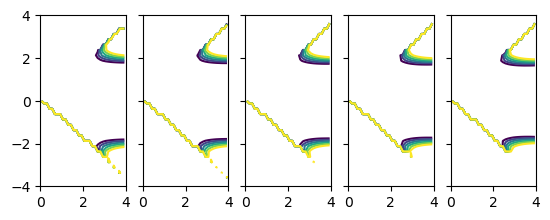

In [ ]:

fig, axs = plt.subplots(1, 5, sharex=True, sharey=True)

for k in range(5):
    axs[k].contour(vperp, vpar, omega_tor[k,:,:], levels=np.linspace(23,27,6))
    axs[k].set_aspect('equal')
    axs[k].set_ylim(-4,4)
    axs[k].set_xlim(0,4)

(array([53., 33., 55., 33., 19., 18., 13.,  3., 10., 17., 15.,  3.,  3.,
         4., 16., 21.,  1.,  2.,  3.,  5.,  7., 14.,  6.,  3.,  2.,  3.,
         3.,  8.,  8.,  6.,  2.,  3.,  4.,  3.,  4.,  7.,  4.,  4.,  3.,
         3.,  2.,  5.,  5.,  2.,  5.,  2.,  3.,  2.,  3.,  3.,  1.,  1.,
         3.,  2.,  2.,  1.,  3.,  1.,  1.,  1.,  2.,  0.,  0.,  2.]),
 array([12.53826937, 12.97463178, 13.41099419, 13.8473566 , 14.28371901,
        14.72008142, 15.15644383, 15.59280624, 16.02916865, 16.46553106,
        16.90189347, 17.33825587, 17.77461828, 18.21098069, 18.6473431 ,
        19.08370551, 19.52006792, 19.95643033, 20.39279274, 20.82915515,
        21.26551756, 21.70187997, 22.13824238, 22.57460479, 23.0109672 ,
        23.44732961, 23.88369202, 24.32005443, 24.75641684, 25.19277924,
        25.62914165, 26.06550406, 26.50186647, 26.93822888, 27.37459129,
        27.8109537 , 28.24731611, 28.68367852, 29.12004093, 29.55640334,
        29.99276575, 30.42912816, 30.86549057, 31.3018

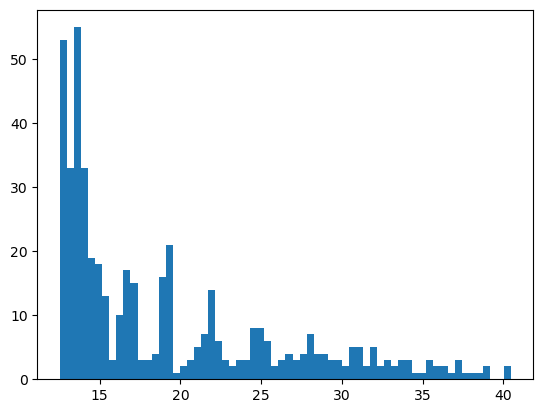

In [93]:
plt.figure()
to_plot = np.abs(omega_tor[3,:,:]) < 200
plt.hist(omega_tor[3,:,:][to_plot], bins=64)

In [44]:
def my_func(x):
    return x, (x**2, x**3)

def my_func2(x, y):
    y1, y2 = y
    return x + y1 + y2

x, y = jax.lax.map(my_func, jnp.array([1.0, 2.0, 3.0, 4.0]), batch_size=2)
z = jtu.tree_map(my_func2, x, y)